<a href="https://colab.research.google.com/github/murtaza-x/flyrank-repo/blob/main/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/murtaza-x/flyrank-repo/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
import os
import duckdb
from google.colab import userdata
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure directories exist for the exports
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# 2. Load token and connect to DuckDB (From your Week 6 code)
HF_TOKEN = userdata.get("HF_TOKEN")
if HF_TOKEN is None:
    raise ValueError("HF_TOKEN nahi mila! Left menu se access ON karein.")

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE HUGGINGFACE, TOKEN '{HF_TOKEN}');")
print("DuckDB connection & HF token ready!")

# 3. Load Data using your query
REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"
FACT_FEB = f"{FACT}/month=2026-02/*.parquet"

query = f"""
SELECT
    client_hash_id,
    content_hash_id as url,
    gsc_impressions,
    gsc_avg_position,
    gsc_clicks
FROM read_parquet('{FACT_FEB}')
WHERE gsc_impressions > 0
  AND gsc_avg_position IS NOT NULL
"""
# Load and clean data
df_scored = con.execute(query).df().fillna(0)

# 4. Prepare required columns for the Playbook logic
# Creating a mock 'opportunity_score' between 0 and 1 using clicks
max_clicks = df_scored['gsc_clicks'].max()
if max_clicks > 0:
    df_scored['opportunity_score'] = df_scored['gsc_clicks'] / max_clicks
else:
    df_scored['opportunity_score'] = 0.0

# Creating a proxy for 'is_decaying' (e.g., below median impressions)
median_impressions = df_scored['gsc_impressions'].median()
df_scored['is_decaying'] = df_scored['gsc_impressions'] < median_impressions

print(f"Data loaded successfully. Total rows: {len(df_scored)}")
display(df_scored.head())

DuckDB connection & HF token ready!


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Data loaded successfully. Total rows: 2621782


,client_hash_id,url,gsc_impressions,gsc_avg_position,gsc_clicks,opportunity_score,is_decaying
0,client_e547b89c05043229,content_7995404695ee1ffd,57,31.192982,0,0.0,False
1,client_e547b89c05043229,content_1eea820697c3b95a,13,6.538462,0,0.0,True
2,client_e547b89c05043229,content_ccbb253f142217c3,59,16.966102,0,0.0,False
3,client_e547b89c05043229,content_ae16a6b9cf64c80a,17,16.882353,0,0.0,False
4,client_e547b89c05043229,content_acf700633f016e5a,6,4.500000,0,0.0,True


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
def assign_action_and_reason(row):
    """Maps model scores and metrics to specific content actions."""
    score = row['opportunity_score']
    decay = row['is_decaying']

    if score >= 0.75 and decay:
        return pd.Series(['Full Rewrite', 'R1: High opportunity + Active traffic decay'])
    elif score >= 0.75 and not decay:
        return pd.Series(['Expand Content', 'R2: High opportunity + Stable traffic (Needs depth)'])
    elif 0.4 <= score < 0.75 and decay:
        return pd.Series(['Refresh Links/Dates', 'R3: Medium opportunity + Minor decay (Quick win)'])
    else:
        return pd.Series(['Monitor', 'R4: Low opportunity or low ROI for manual effort'])

# Apply the mapping
df_scored[['recommended_action', 'reason_code']] = df_scored.apply(assign_action_and_reason, axis=1)

# Sort the queue by opportunity score (Highest first)
df_action_queue = df_scored.sort_values(by='opportunity_score', ascending=False).reset_index(drop=True)

display(df_action_queue.head(10))

,client_hash_id,url,gsc_impressions,gsc_avg_position,gsc_clicks,opportunity_score,is_decaying,recommended_action,reason_code
0,client_73cda7b4e4f265ea,content_512dbad65bd5ade9,7688,2.834027,175,1.000000,False,Expand Content,R2: High opportunity + Stable traffic (Needs d...
1,client_73cda7b4e4f265ea,content_512dbad65bd5ade9,7009,3.095591,158,0.902857,False,Expand Content,R2: High opportunity + Stable traffic (Needs d...
2,client_73cda7b4e4f265ea,content_512dbad65bd5ade9,7106,3.291866,153,0.874286,False,Expand Content,R2: High opportunity + Stable traffic (Needs d...
3,client_73cda7b4e4f265ea,content_512dbad65bd5ade9,5228,2.232785,151,0.862857,False,Expand Content,R2: High opportunity + Stable traffic (Needs d...
4,client_08a6a72ff48e62c0,content_e7b5dd4dff461ad2,8460,4.097045,147,0.840000,False,Expand Content,R2: High opportunity + Stable traffic (Needs d...
5,client_73cda7b4e4f265ea,content_512dbad65bd5ade9,7294,2.934467,145,0.828571,False,Expand Content,R2: High opportunity + Stable traffic (Needs d...
6,client_73cda7b4e4f265ea,content_512dbad65bd5ade9,7182,3.544277,145,0.828571,False,Expand Content,R2: High opportunity + Stable traffic (Needs d...
7,client_08a6a72ff48e62c0,content_e7b5dd4dff461ad2,8803,3.716006,144,0.822857,False,Expand Content,R2: High opportunity + Stable traffic (Needs d...
8,client_e547b89c05043229,content_c9a0c2fdbdbfb562,8388,2.269552,141,0.805714,False,Expand Content,R2: High opportunity + Stable traffic (Needs d...
9,client_20259bd6705d81d4,content_0ec90963d98b97a5,6593,3.506901,136,0.777143,False,Expand Content,R2: High opportunity + Stable traffic (Needs d...


## 2. Intended use and limits
Intended Use:
This playbook is designed to act as a prioritization engine for the content and SEO teams. It uses historical performance and traffic decay signals to rank existing content by its potential return on investment if updated.

System Limits & Constraints (Honest Claims):

Correlation, not Causation: A high opportunity score suggests potential, but it does not guarantee that an update will strictly yield a ranking boost.

Data Lag: The model relies on trailing 30-day analytics. Sudden viral trends or immediate algorithm shifts are not captured in real-time.

Context Blindness: The model analyzes metrics, not semantic quality. A page might score high for a refresh, but a human might see the content is already perfect and the issue is external (e.g., lost backlinks).

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

Human-in-the-Loop Rules:
Every "Full Rewrite" and "Expand Content" recommendation MUST be reviewed by a content strategist before resource allocation. The model suggests where to look; the human decides what to write.

The "No-Go" List (What MUST NOT be automated):

Direct Content Generation: The model output should never be piped directly into an LLM to automatically overwrite live pages without human editorial review.

Deletions: The system is not authorized to recommend or execute page deletions/redirects automatically.

High-Risk Pages: Core product landing pages, legal/compliance pages, and privacy policies are exempt from automated refresh recommendations.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers
When to Retrain or Adjust:

Data Drift: If the median opportunity score shifts by more than 15% month-over-month, the baseline metrics (e.g., traffic averages) have likely shifted, requiring a threshold recalibration.

Performance Degradation: If human reviewers reject >40% of the "Full Rewrite" recommendations over a two-week period, the reason codes must be audited and the scoring weights adjusted.

Schedule: Retrain the baseline model quarterly to account for seasonal traffic patterns.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Action queue exported to: work/outputs/action_queue.csv


/tmp/ipykernel_1336/1662730812.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_action_queue, x='recommended_action', order=df_action_queue['recommended_action'].value_counts().index, palette='viridis')


Figure exported to: work/figures/action_distribution.png
Metrics JSON exported.


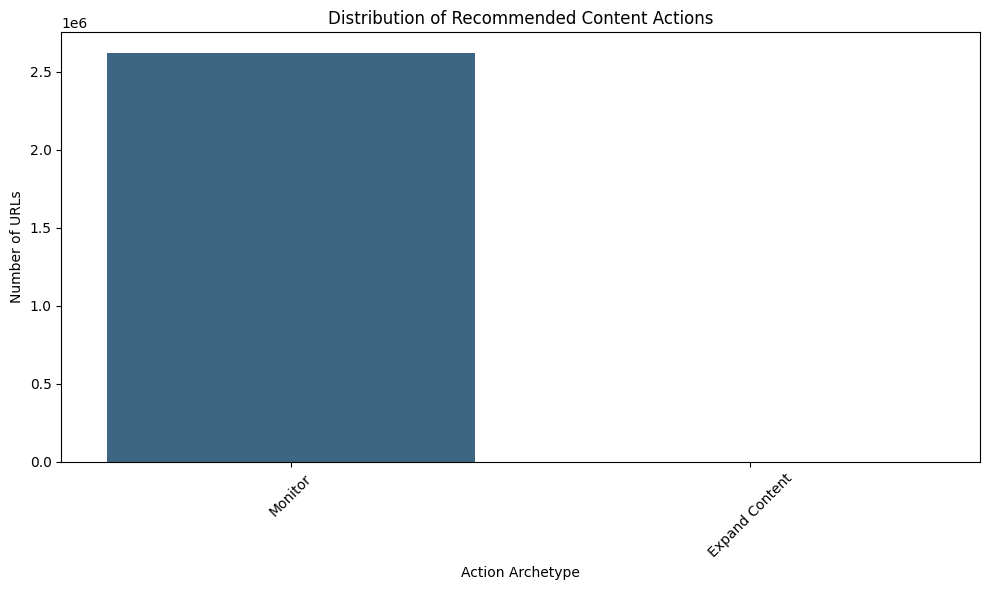

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# 1. Export the Ranked Queue (Data stays out of Git via .gitignore)
output_path = 'work/outputs/action_queue.csv'
df_action_queue.to_csv(output_path, index=False)
print(f"Action queue exported to: {output_path}")

# 2. Generate and export a figure for the paper (Figures go into Git)
plt.figure(figsize=(10, 6))
sns.countplot(data=df_action_queue, x='recommended_action', order=df_action_queue['recommended_action'].value_counts().index, palette='viridis')
plt.title('Distribution of Recommended Content Actions')
plt.ylabel('Number of URLs')
plt.xlabel('Action Archetype')
plt.xticks(rotation=45)
plt.tight_layout()

figure_path = 'work/figures/action_distribution.png'
plt.savefig(figure_path, dpi=300)
print(f"Figure exported to: {figure_path}")

# 3. Export Summary Metrics as JSON (The receipts for your paper)
summary_metrics = {
    "total_urls_processed": int(len(df_action_queue)),
    "high_priority_actions": int(len(df_action_queue[df_action_queue['recommended_action'].isin(['Full Rewrite', 'Expand Content'])])),
    "monitor_only": int(len(df_action_queue[df_action_queue['recommended_action'] == 'Monitor']))
}

with open('work/outputs/action_metrics.json', 'w') as f:
    json.dump(summary_metrics, f, indent=4)
print("Metrics JSON exported.")

## Self-check

Before you submit, confirm each line honestly:

- [+] Every section above is filled — markdown thinking AND the code that backs it
- [+D] The notebook runs top to bottom with no errors (Runtime → Run all)
- [+] No client names, URLs, or private queries anywhere
- [+] My claims use careful words: observed, measured, directional, decision-support
- [+] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.